## **Load and Merge Data** 

In [29]:
# import all necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import pickle

In [2]:
# Set display to show all columns
pd.set_option('display.max_columns', None)

# read in datasets
links = pd.read_csv('links.csv')
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv') 
tags = pd.read_csv('tags.csv')


In [3]:
# inner join all tables into df
df = pd.merge(movies, ratings, on='movieId', how='inner')
df = pd.merge(df,tags, on = 'movieId', how = 'inner')
df = pd.merge(df, links, on = 'movieId', how = 'inner')

df.head()

,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703,336,pixar,1139045764,114709,862.0
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703,474,pixar,1137206825,114709,862.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703,567,fun,1525286013,114709,862.0
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962,336,pixar,1139045764,114709,862.0
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962,474,pixar,1137206825,114709,862.0


## **Exploratory Data Analysis**

In [4]:
# check for nulls in merged data
df.isnull().sum()

movieId        0
title          0
genres         0
userId_x       0
rating         0
timestamp_x    0
userId_y       0
tag            0
timestamp_y    0
imdbId         0
tmdbId         0
dtype: int64

In [5]:
# create function to quickly input chart settings
def chart_settings(title, xaxis_label, yaxis_label,
                   labelsize=10,
                   labelrotation=0):

    plt.title(title)

    plt.xlabel(xaxis_label)
    plt.ylabel(yaxis_label)

    plt.tick_params(
        axis='x',
        labelsize=labelsize,
        labelrotation=labelrotation
    )


### **Genre Analysis**

In [6]:
# split genres column and explode (1 row per genre) for EDA

df['genres'] = df['genres'].astype(str)
df['genres'] = df['genres'].str.split('|')
genre_df = df.explode('genres')

genre_df.head()


,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y,imdbId,tmdbId
0,1,Toy Story (1995),Adventure,1,4.0,964982703,336,pixar,1139045764,114709,862.0
0,1,Toy Story (1995),Animation,1,4.0,964982703,336,pixar,1139045764,114709,862.0
0,1,Toy Story (1995),Children,1,4.0,964982703,336,pixar,1139045764,114709,862.0
0,1,Toy Story (1995),Comedy,1,4.0,964982703,336,pixar,1139045764,114709,862.0
0,1,Toy Story (1995),Fantasy,1,4.0,964982703,336,pixar,1139045764,114709,862.0


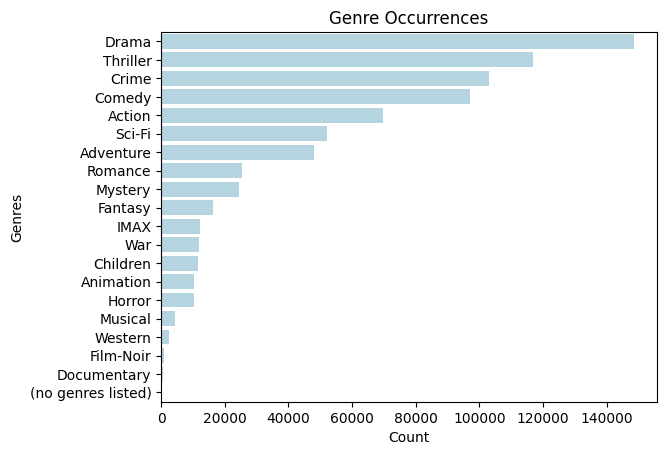

In [7]:
# barplot for Genre Occurrences

genre_counts = genre_df['genres'].value_counts()

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    color = 'lightblue'
)

chart_settings(title = 'Genre Occurrences', xaxis_label= 'Count', yaxis_label= 'Genres')

# Dramas appear the most in the dataset

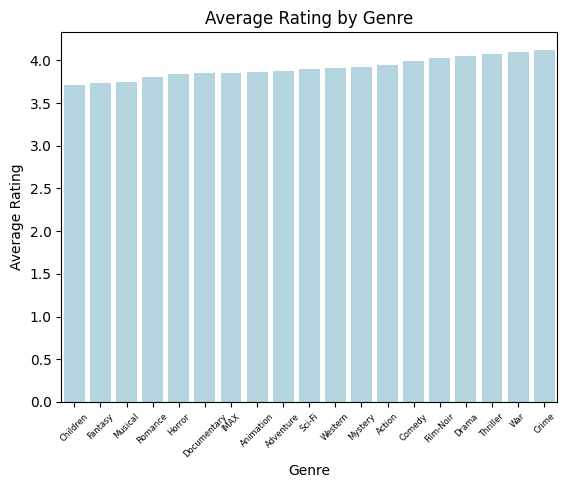

In [8]:
# Average rating by genre

# filter out rows with no genre
genre_df = genre_df[
    genre_df['genres'] != '(no genres listed)'
]
# group by genre, average rating
genre_avg = genre_df.groupby('genres')['rating'].mean().sort_values()

sns.barplot(
    x = genre_avg.index,
    y = genre_avg.values,
    color = 'lightblue'
)

chart_settings(title = 'Average Rating by Genre', xaxis_label= 'Genre', yaxis_label= 'Average Rating', labelsize = 6, labelrotation= 45)


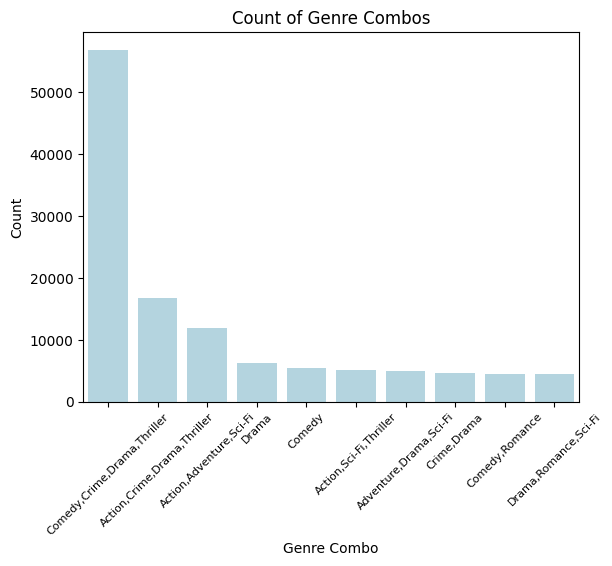

In [9]:
# which genre combos appear most frequently?

df['genre_combo'] = df['genres'].apply(lambda x: ','.join(sorted(x)))
top_10_genre_combos = df['genre_combo'].value_counts().sort_values(ascending = False)[0:10]

sns.barplot(
    x = top_10_genre_combos.index,
    y = top_10_genre_combos.values,
    color = 'lightblue'
)

chart_settings(title = 'Count of Genre Combos', xaxis_label= 'Genre Combo', yaxis_label= 'Count', labelsize = 8, labelrotation= 45)

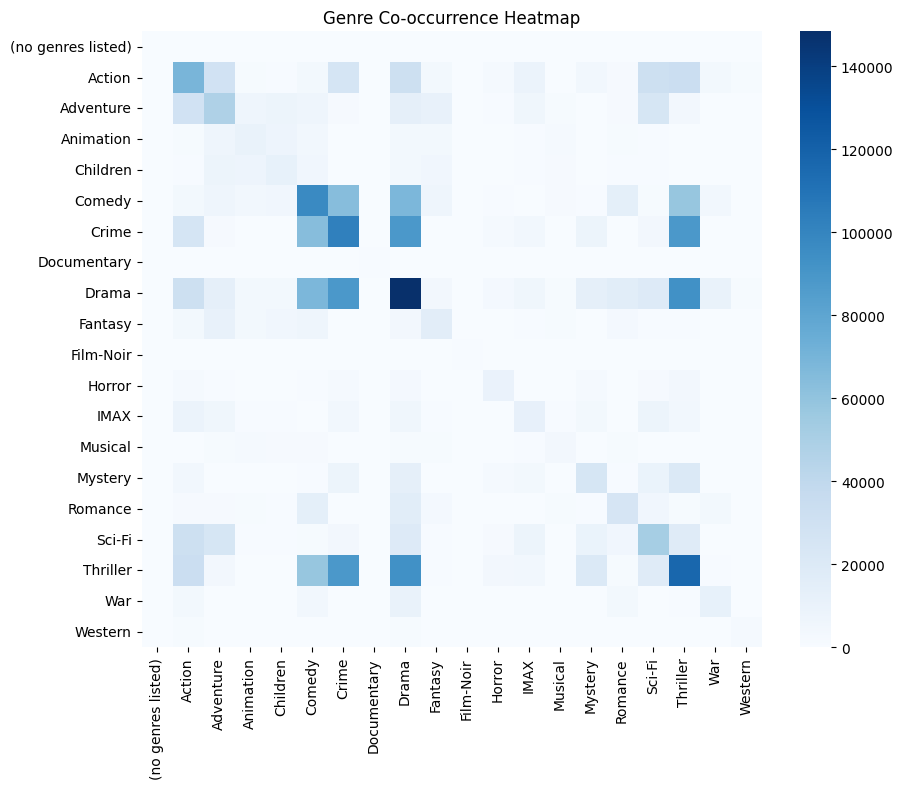

In [10]:
# heatmap to display correlation within genres
# diagonal -> how many movies contain this genre at all?
# off diagonal -> how many movies contain both genres?

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genres'])

genre_df_heatmap = pd.DataFrame(genre_matrix, columns=mlb.classes_)

co_matrix = genre_df_heatmap.T.dot(genre_df_heatmap)

plt.figure(figsize=(10, 8))

sns.heatmap(
    co_matrix,
    cmap='Blues',
    annot=False  # set True if matrix is small
)

plt.title("Genre Co-occurrence Heatmap")
plt.show()

### **Ratings Analysis**

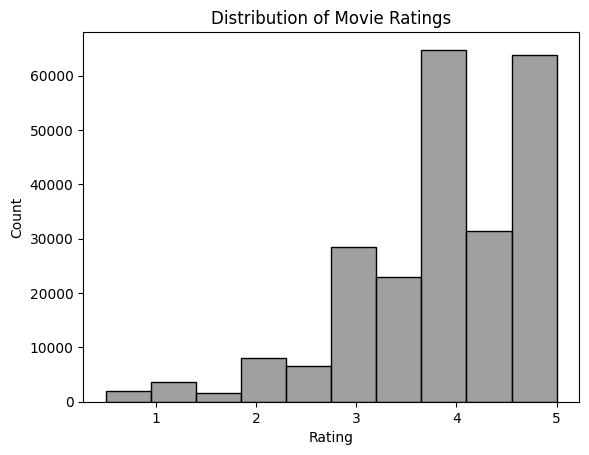

In [11]:
# distribution of movie ratings
sns.histplot(data=df, x=df['rating'], bins = 10, color = 'gray')

chart_settings(title = 'Distribution of Movie Ratings', xaxis_label= 'Rating', yaxis_label= 'Count')

Text(0.5, 1.0, 'Ratings Boxplot')

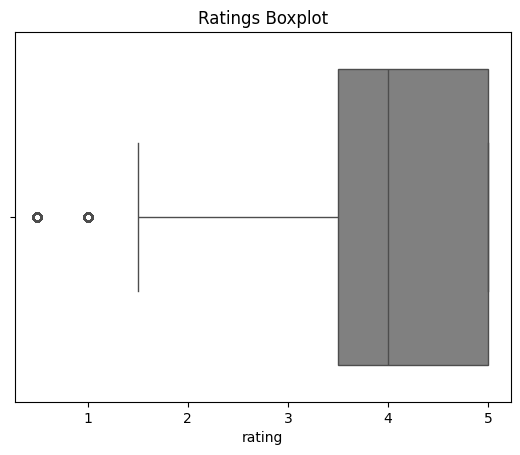

In [12]:
# boxplot of ratings

sns.boxplot(data = df, x = df['rating'], color = 'gray')
plt.title('Ratings Boxplot')

### **Tags Analysis**

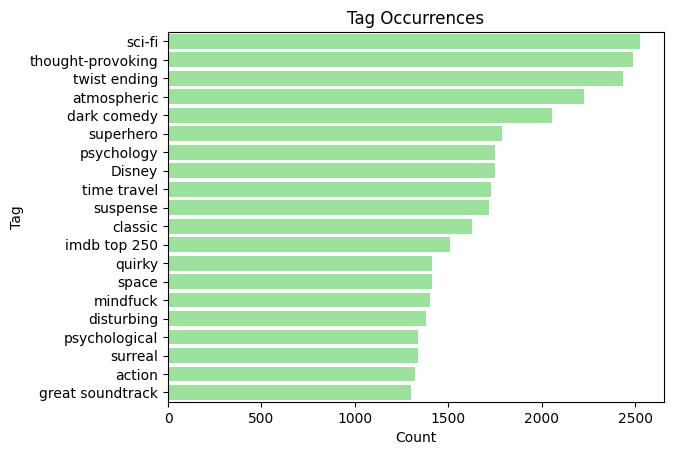

In [13]:
# barplot for Tag Occurrences

tags_counts = df['tag'].value_counts()[:20]

sns.barplot(
    x=tags_counts.values,
    y=tags_counts.index,
    color = 'lightgreen'
)

chart_settings(title = 'Tag Occurrences', xaxis_label= 'Count', yaxis_label= 'Tag')

# Dramas appear the most in the dataset

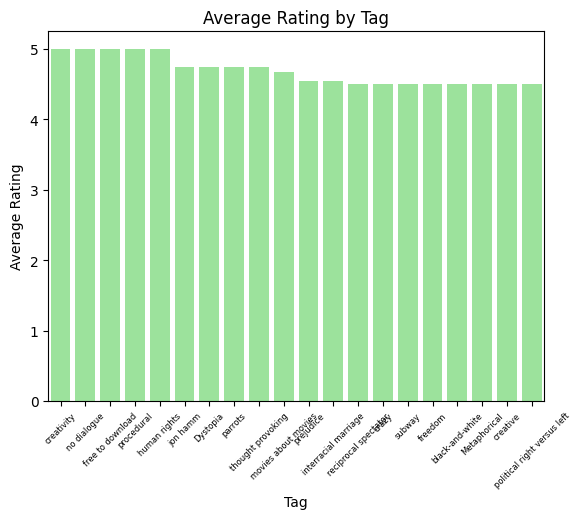

In [14]:
# Average rating by tag
# group by genre, average rating
tag_avg = genre_df.groupby('tag')['rating'].mean().sort_values(ascending = False)[:20]

sns.barplot(
    x = tag_avg.index,
    y = tag_avg.values,
    color = 'lightgreen'
)

chart_settings(title = 'Average Rating by Tag', xaxis_label= 'Tag', yaxis_label= 'Average Rating', labelsize = 6, labelrotation= 45)

In [15]:
df[df['tag'].map(df['tag'].value_counts()) >= 1000]

,movieId,title,genres,userId_x,rating,timestamp_x,userId_y,tag,timestamp_y,imdbId,tmdbId,genre_combo
1517,16,Casino (1995),"[Crime, Drama]",6,4.0,845553819,474,Mafia,1137181640,112641,524.0,"Crime,Drama"
1518,16,Casino (1995),"[Crime, Drama]",18,4.5,1461311583,474,Mafia,1137181640,112641,524.0,"Crime,Drama"
1519,16,Casino (1995),"[Crime, Drama]",28,2.5,1234570375,474,Mafia,1137181640,112641,524.0,"Crime,Drama"
1520,16,Casino (1995),"[Crime, Drama]",42,5.0,996218017,474,Mafia,1137181640,112641,524.0,"Crime,Drama"
1521,16,Casino (1995),"[Crime, Drama]",61,4.0,1145531659,474,Mafia,1137181640,112641,524.0,"Crime,Drama"
...,...,...,...,...,...,...,...,...,...,...,...,...
233139,180031,The Shape of Water (2017),"[Adventure, Drama, Fantasy]",567,4.0,1525284143,567,atmospheric,1525284150,5580390,399055.0,"Adventure,Drama,Fantasy"
233140,180031,The Shape of Water (2017),"[Adventure, Drama, Fantasy]",567,4.0,1525284143,567,dreamlike,1525284163,5580390,399055.0,"Adventure,Drama,Fantasy"
233141,180031,The Shape of Water (2017),"[Adventure, Drama, Fantasy]",599,3.5,1518298493,567,atmospheric,1525284150,5580390,399055.0,"Adventure,Drama,Fantasy"
233142,180031,The Shape of Water (2017),"[Adventure, Drama, Fantasy]",599,3.5,1518298493,567,dreamlike,1525284163,5580390,399055.0,"Adventure,Drama,Fantasy"


<Axes: xlabel='tag', ylabel='genres'>

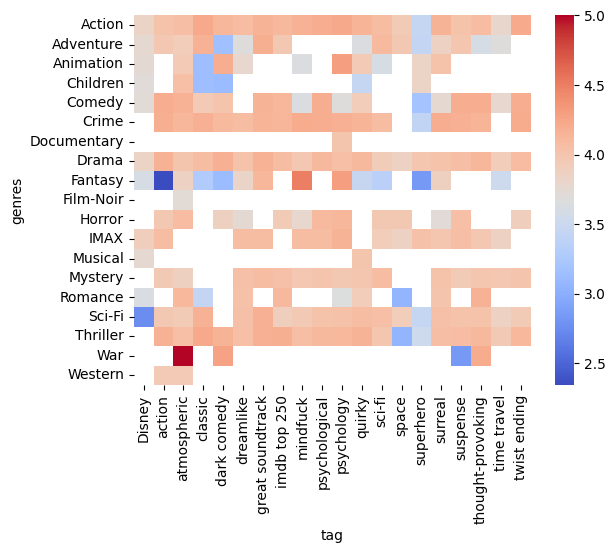

In [16]:
# heatmap to analyze correlations between genre and top 20 tags
top_tags = genre_df['tag'].value_counts().sort_values(ascending = False)[:20].index
df_top = genre_df[genre_df['tag'].isin(top_tags)]

pivot = df_top.pivot_table(
    values='rating',
    index='genres',
    columns='tag',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='coolwarm')

In [17]:
top_tags = genre_df['tag'].value_counts().sort_values(ascending = False)[:19].index
print(top_tags)

Index(['thought-provoking', 'Disney', 'sci-fi', 'twist ending', 'atmospheric',
       'dark comedy', 'superhero', 'psychology', 'suspense', 'classic',
       'time travel', 'action', 'great soundtrack', 'imdb top 250', 'surreal',
       'mindfuck', 'psychological', 'quirky', 'dreamlike'],
      dtype='str', name='tag')


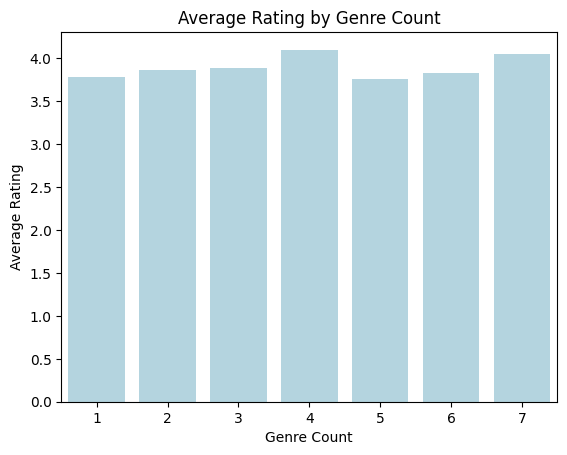

In [18]:
# feature engineering a genre_count
df['genre_count'] = df['genres'].apply(len)

genre_count_df = df.groupby('genre_count')['rating'].mean()

sns.barplot(
    x = genre_count_df.index,
    y = genre_count_df.values,
    color = 'lightblue'
)

chart_settings(title = 'Average Rating by Genre Count', xaxis_label = 'Genre Count', yaxis_label= 'Average Rating')

                                

## **Cosine Similarity**

In [19]:
# Create a movie-level dataset so we can apply cosine similarity
movie_df = df.groupby(['movieId', 'title', 'genre_combo', 'genre_count', 'tmdbId']).agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count'),
    all_tags=('tag', lambda x: ' '.join(x.dropna().unique())) # aggregate all tags into one column
).reset_index()

In [20]:
movie_df.head()

,movieId,title,genre_combo,genre_count,tmdbId,avg_rating,num_ratings,all_tags
0,1,Toy Story (1995),"Adventure,Animation,Children,Comedy,Fantasy",5,862.0,3.920930,645,pixar fun
1,2,Jumanji (1995),"Adventure,Children,Fantasy",3,8844.0,3.431818,440,fantasy magic board game Robin Williams game
2,3,Grumpier Old Men (1995),"Comedy,Romance",2,15602.0,3.259615,104,moldy old
3,5,Father of the Bride Part II (1995),Comedy,1,11862.0,3.071429,98,pregnancy remake
4,7,Sabrina (1995),"Comedy,Romance",2,11860.0,3.185185,54,remake


In [21]:
# Combine genre + tags into one text blob per movie
movie_df['features'] = movie_df['genre_combo'].str.replace(',', ' ') + ' ' + movie_df['all_tags']

# TF-IDF vectorize — turns text into a numeric matrix
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movie_df['features'])

In [22]:
# coords -> (0,36) -> 0 represents the movie in row 0, 36 is the mapping to a specific word in the TF-IDF learned vocablary. Values represent the TF-IDF value (essentially importance of this word relative to the dataset)

print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8522 stored elements and shape (1554, 1675)>
  Coords	Values
  (0, 36)	0.24891058815028796
  (0, 75)	0.3275086638164129
  (0, 274)	0.314826435264458
  (0, 317)	0.1757121271881088
  (0, 529)	0.2994955815904686
  (0, 1140)	0.5667282615756892
  (0, 586)	0.5384353558123329
  (1, 36)	0.13636491040956472
  (1, 274)	0.1724767072322342
  (1, 529)	0.3281554911355223
  (1, 923)	0.28882881847698655
  (1, 177)	0.3526908949064878
  (1, 594)	0.668024869883529
  (1, 1261)	0.3207598566917372
  (1, 1649)	0.2949801758226488
  (2, 317)	0.18480041841888153
  (2, 1269)	0.22133714234810337
  (2, 990)	0.6770741003647169
  (2, 1079)	0.6770741003647169
  (3, 317)	0.23398194574094672
  (3, 1170)	0.7169917877883076
  (3, 1233)	0.6566393418851837
  (4, 317)	0.31143421926889076
  (4, 1269)	0.3730075976675708
  (4, 1233)	0.8739988896735763
  :	:
  (1551, 1309)	0.19521702419024656
  (1551, 546)	0.19521702419024656
  (1551, 22)	0.17161654239979685
  (1551,

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
# Shape: (n_movies, n_movies) — every movie vs every other movie

In [24]:
# this output is a matrix of all movies on both axes. the values are the cosine similary (the similarities of the angles of the vectors)

print(cosine_sim)

[[1.         0.18652402 0.03247167 ... 0.02193481 0.11843903 0.137741  ]
 [0.18652402 1.         0.         ... 0.         0.06488646 0.        ]
 [0.03247167 0.         1.         ... 0.02306933 0.         0.05292756]
 ...
 [0.02193481 0.         0.02306933 ... 1.         0.10937102 0.15697311]
 [0.11843903 0.06488646 0.         ... 0.10937102 1.         0.12546398]
 [0.137741   0.         0.05292756 ... 0.15697311 0.12546398 1.        ]]


In [25]:
# Build a reverse index: title → row position
# index for each movie
indices = pd.Series(movie_df.index, index=movie_df['title']).drop_duplicates()

In [26]:
print(indices)

title
Toy Story (1995)                         0
Jumanji (1995)                           1
Grumpier Old Men (1995)                  2
Father of the Bride Part II (1995)       3
Sabrina (1995)                           4
                                      ... 
Game Night (2018)                     1549
Tomb Raider (2018)                    1550
Deadpool 2 (2018)                     1551
Solo: A Star Wars Story (2018)        1552
Gintama: The Movie (2010)             1553
Length: 1554, dtype: int64


In [27]:
# create function to return list of recommended movies based on title parameter
def get_recommendations_weighted(title, n=10):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx])) # enumerates to (movie_index, similarity_score) -> any given movie's similarity to all other movies -> for movie 0, (0, 1) indicates that it has perfect similarity with movie 0
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) # sorts by scores from highest to lowest
    sim_scores = sim_scores[1:n+1] # first ranked movie will always be itself, so start from the next movie
    
    movie_indices = [i[0] for i in sim_scores]
    results = movie_df.iloc[movie_indices].copy()
    
    # Weighted score: 70% similarity, 30% normalized rating
    results['sim_score'] = [s[1] for s in sim_scores]
    results['norm_rating'] = results['avg_rating'] / 5.0 # max rating is 5, dividing by 5 will normalize the scores
    results['final_score'] = 0.7 * results['sim_score'] + 0.3 * results['norm_rating'] #70% score, 30% normalized rating
    
    return results[['title', 'genre_combo', 'avg_rating', 'final_score']]\
               .sort_values('final_score', ascending=False)

In [28]:
get_recommendations_weighted('Toy Story (1995)')

,title,genre_combo,avg_rating,final_score
543,"Bug's Life, A (1998)","Adventure,Animation,Children,Comedy",3.516304,0.762332
664,Toy Story 2 (1999),"Adventure,Animation,Children,Comedy,Fantasy",3.860825,0.588770
1268,"Cat Returns, The (Neko no ongaeshi) (2002)","Adventure,Animation,Children,Fantasy",3.750000,0.567134
1506,Guardians of the Galaxy 2 (2017),"Action,Adventure,Sci-Fi",3.925926,0.564338
1261,Kiki's Delivery Service (Majo no takkyûbin) (1...,"Adventure,Animation,Children,Drama,Fantasy",4.058824,0.563850
1427,Sintel (2010),"Animation,Fantasy",3.500000,0.556168
1027,Sinbad: Legend of the Seven Seas (2003),"Adventure,Animation,Children,Fantasy",3.666667,0.528012
641,Who Framed Roger Rabbit? (1988),"Adventure,Animation,Children,Comedy,Crime,Fant...",3.572165,0.520260
616,Big (1988),"Comedy,Drama,Fantasy,Romance",3.719780,0.513009
248,Alice in Wonderland (1951),"Adventure,Animation,Children,Fantasy,Musical",3.375000,0.511430


## **Use TMDB API to fetch movie poster URL**

In [ ]:
import requests
import time
from tqdm import tqdm  # pip install tqdm — gives you a progress bar

TMDB_API_KEY = 'your_api_key_here'
TMDB_IMAGE_BASE = 'https://image.tmdb.org/t/p/w300'

def fetch_poster_url(tmdb_id):
    """Fetch poster URL for a single movie given its TMDB ID."""
    try:
        if pd.isna(tmdb_id):
            return None
            
        url = f'https://api.themoviedb.org/3/movie/{int(tmdb_id)}?api_key={TMDB_API_KEY}'
        response = requests.get(url, timeout=5)
        
        if response.status_code == 200:
            data = response.json()
            poster_path = data.get('poster_path')
            return TMDB_IMAGE_BASE + poster_path if poster_path else None
        else:
            return None
            
    except Exception:
        return None

# Apply to every row — with a small delay to respect TMDB rate limits
poster_urls = []

for tmdb_id in tqdm(movie_df['tmdbId'], desc="Fetching posters"):
    url = fetch_poster_url(tmdb_id)
    poster_urls.append(url)
    time.sleep(0.05)  # 50ms delay — TMDB allows 40 req/sec on free tier

movie_df['poster_url'] = poster_urls

In [ ]:
# How many posters did we successfully fetch?
fetched = movie_df['poster_url'].notna().sum()
total = len(movie_df)
print(f"Posters fetched: {fetched}/{total} ({fetched/total*100:.1f}%)")

# Preview
movie_df[['title', 'tmdbId', 'poster_url']].dropna(subset=['poster_url']).head()

In [ ]:
# Re-save your artifacts with poster URLs baked in
movie_df.to_csv('movie_data.csv', index=False)

# Update your pickle too if you're using one
with open('recommender_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'cosine_sim': cosine_sim, 
        'movie_df': movie_df, 
        'indices': indices
    }, f)

In [30]:
# Before running, quickly verify your artifacts have what the API expects
import pickle, numpy as np

with open('recommender_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

print(artifacts.keys())           # should show: movie_df, indices, cosine_sim
print(artifacts['movie_df'].columns.tolist())  # should include poster_url, avg_rating etc
print(np.load('cosine_sim.npy').shape)         # should be (n_movies, n_movies)

dict_keys(['cosine_sim', 'movie_df', 'indices'])
['movieId', 'title', 'genre_combo', 'genre_count', 'tmdbId', 'avg_rating', 'num_ratings', 'all_tags', 'features', 'poster_url']
(1554, 1554)
